# Actividad entregable - Semana 8

Juan Esteban Camacho Castro, Juan Diego Serpa Ruiz

## Importación de librerias y dataset

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("S07_PD_Camacho_Serpa_DatasetSinOutliers.csv")

In [3]:
df.shape

(620000, 23)

In [4]:
df[["edad_cliente", "precio_unitario", "monto_compra", "unidades_vendidas"]].describe()

,edad_cliente,precio_unitario,monto_compra,unidades_vendidas
count,620000.000000,599000.000000,5.990000e+05,620000.000000
mean,47.295331,340202.689649,6.249332e+05,4.676960
std,21.971281,211860.854796,5.390458e+05,16.505427
min,0.000000,0.000000,0.000000e+00,0.000000
25%,31.000000,169700.000000,2.227000e+05,1.000000
50%,47.000000,305800.000000,4.568000e+05,1.000000
75%,62.000000,484400.000000,8.574000e+05,3.000000
max,120.000000,956450.000000,1.809450e+06,100.000000


In [5]:
print(df['edad_cliente'].max()-df['edad_cliente'].min())
print(df['precio_unitario'].max()-df['precio_unitario'].min())
print(df['monto_compra'].max()-df['monto_compra'].min())
print(df['unidades_vendidas'].max()-df['unidades_vendidas'].min())

120
956450.0
1809450.0
100


## Rangos antes de escalar

La columna monto_compra es la más amplia, ya que su rango es de 1809450, mientras que la más angosta es la de unidades_vendidas que tiene un rango de 100

## Entrenamiento

In [6]:
df_entrenamiento, df_prueba = train_test_split(df, test_size=0.2, random_state=42)

In [7]:
print(len(df_entrenamiento))
print(len(df_prueba))

496000
124000


## Por qué evito la fuga de datos

Solo calculo el escalador con el conjunto de entrenamiento ya que si también lo hago con el conjunto de prueba, este se va a "contaminar" y no va a aprender a comparar si se le da un dato nuevo, ya que tendría todo de "memoria" 

## Escalado

Usamos RobustScaler ya que hay outliers muy grandes en todo el dataset, algo que afectaría gravemente a Min-Max y a Z-Score

In [8]:
escalador_edad = StandardScaler()
escalador_precio = MinMaxScaler()
escalador_monto = RobustScaler()
escalador_unidades = RobustScaler()

In [9]:
escalador_edad.fit(df_entrenamiento[["edad_cliente"]])
escalador_precio.fit(df_entrenamiento[['precio_unitario']])
escalador_monto.fit(df_entrenamiento[["monto_compra"]])
escalador_unidades.fit(df_entrenamiento[["unidades_vendidas"]])

RobustScaler()

In [10]:
df_entrenamiento["edad_cliente_escalada"] = escalador_edad.transform(df_entrenamiento[["edad_cliente"]])
df_prueba["edad_cliente_escalada"] = escalador_edad.transform(df_prueba[["edad_cliente"]])

In [11]:
df_entrenamiento["precio_unitario_escalada"] = escalador_precio.transform(df_entrenamiento[["precio_unitario"]])
df_prueba["precio_unitario_escalada"] = escalador_precio.transform(df_prueba[["precio_unitario"]])

In [12]:
df_entrenamiento["monto_compra_robusto"] = escalador_monto.transform(df_entrenamiento[["monto_compra"]])
df_prueba["monto_compra_robusto"] = escalador_monto.transform(df_prueba[["monto_compra"]])

In [13]:
df_entrenamiento["unidades_vendidas_robusto"] = escalador_unidades.transform(df_entrenamiento[["unidades_vendidas"]])
df_prueba["unidades_vendidas_robusto"] = escalador_unidades.transform(df_prueba[["unidades_vendidas"]])

In [14]:
df_entrenamiento.filter(like="_escalada").describe()
df_prueba.filter(like="_escalada").describe()

,edad_cliente_escalada,precio_unitario_escalada
count,124000.000000,119885.000000
mean,0.003369,0.355248
std,0.996704,0.221455
min,-2.150509,0.000000
25%,-0.740504,0.177113
50%,-0.012759,0.318888
75%,0.669502,0.506352
max,3.307576,1.000000


In [15]:
df_entrenamiento.filter(like="_robusto").describe()
df_prueba.filter(like="_robusto").describe()

,monto_compra_robusto,unidades_vendidas_robusto
count,119885.000000,124000.000000
mean,0.258115,1.802823
std,0.843459,8.162433
min,-0.717852,-0.500000
25%,-0.369446,0.000000
50%,-0.002826,0.000000
75%,0.612969,1.000000
max,2.123175,49.500000


## Histograma

### edad_cliente

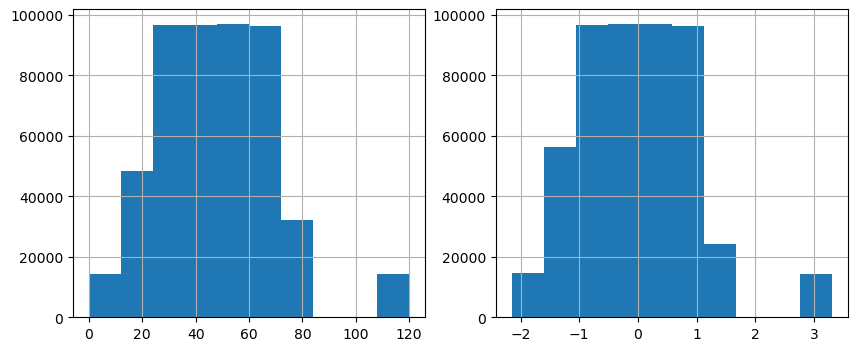

In [16]:
fig, ejes = plt.subplots(1, 2, figsize=(10, 4))
df_entrenamiento["edad_cliente"].hist(ax=ejes[0])
df_entrenamiento["edad_cliente_escalada"].hist(ax=ejes[1])
plt.show()

### precio_unitario

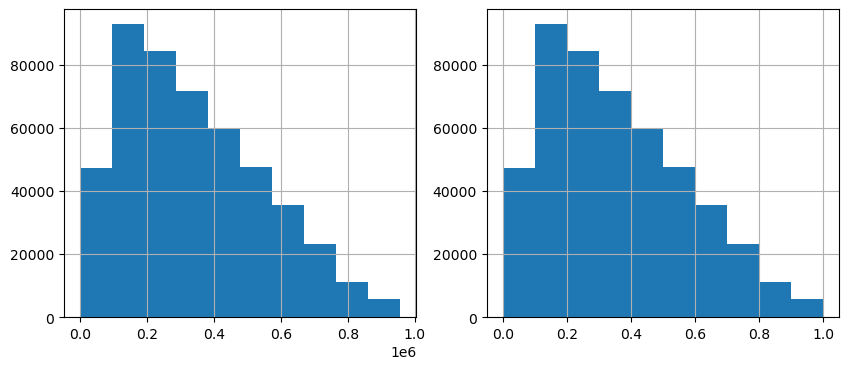

In [17]:
fig, ejes = plt.subplots(1, 2, figsize=(10, 4))
df_entrenamiento["precio_unitario"].hist(ax=ejes[0])
df_entrenamiento["precio_unitario_escalada"].hist(ax=ejes[1])
plt.show()

### monto_compra

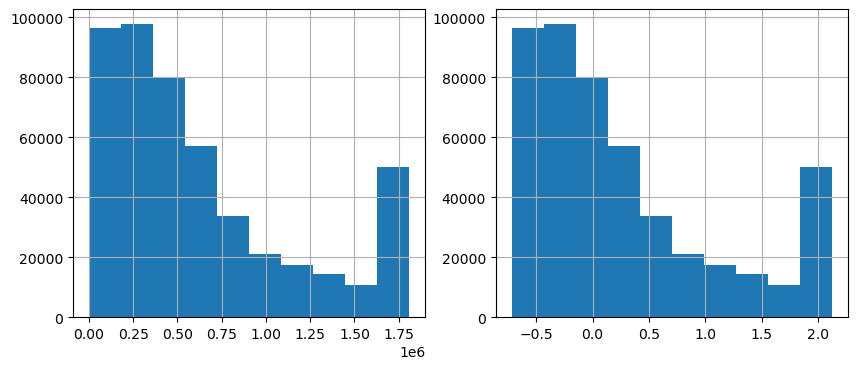

In [18]:
fig, ejes = plt.subplots(1, 2, figsize=(10, 4))
df_entrenamiento["monto_compra"].hist(ax=ejes[0])
df_entrenamiento["monto_compra_robusto"].hist(ax=ejes[1])
plt.show()

### unidades_vendidas

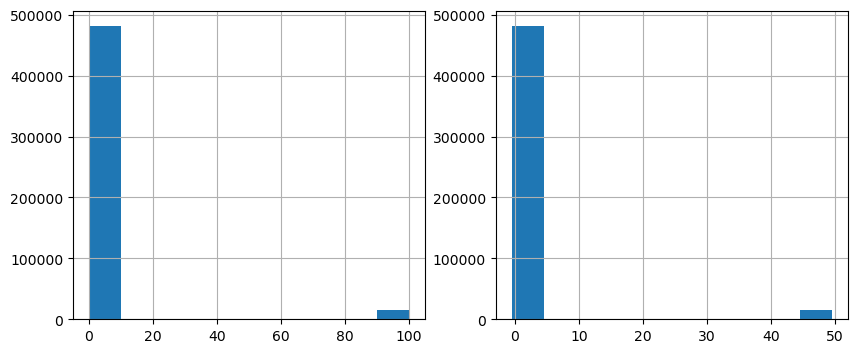

In [19]:
fig, ejes = plt.subplots(1, 2, figsize=(10, 4))
df_entrenamiento["unidades_vendidas"].hist(ax=ejes[0])
df_entrenamiento["unidades_vendidas_robusto"].hist(ax=ejes[1])
plt.show()

## Comparación antes y después

Es verdad, ambos histogramas tienen exactamente la misma forma pero la escala del eje x ajustada, lo que muestra que no se les hizo ninguna conversión "extraña" a los datos sino simplemente un escalado.

## Boxplot

<Axes: >

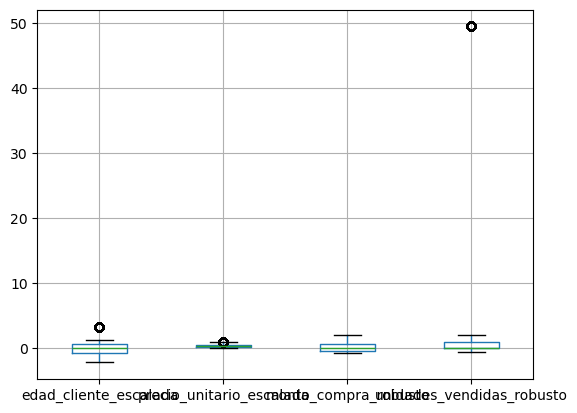

In [20]:
df_entrenamiento[["edad_cliente_escalada", "precio_unitario_escalada", "monto_compra_robusto", "unidades_vendidas_robusto"]].boxplot()

## Boxplot comparativo

Todos los boxplot tienen una escala similar, por eso se pueden visualizar bien las 4 variables ya que fueron escaladas, antes de esto monto_compra opacaría enormemente a las demás columnas debido a su escala.

## Justificación de escalado por columna

Se eligió StandardScaler (Z-Score) para la edad_cliente dado que presenta una distribución simétrica y estable, con una media y mediana idénticas (47 años) y sin valores atípicos que corrompan el cálculo. 
Para el precio_unitario, se optó por MinMaxScaler con el fin de acotar el catálogo de valores a un espacio estricto entre 0 y 1, conservando la forma de la distribución original. 
Finalmente, tanto para el monto_compra como para las unidades_vendidas, se implementó RobustScaler. Al evaluar la dispersión, ambas variables revelaron un fuerte sesgo positivo y colas derechas pesadas (como el caso de transacciones máximas de 100 unidades frente a un percentil 75 de apenas 3). Al utilizar la mediana y el rango intercuartílico, esta técnica aísla esos valores extremos y evita que las compras inusualmente grandes distorsionen el peso de las transacciones habituales al entrenar el modelo.

## Conservación de variables originales y escaladas

Para la estructuración final de los datos, se tomó la decisión de conservar ambas versiones de las variables numéricas. En lugar de sobrescribir los datos originales aplicando la transformación directamente, se optó por generar nuevas columnas con sufijos descriptivos (_escalada y _robusto). 
Esto se hizo porque permite verificar paso a paso que las transformaciones matemáticas se aplicaron correctamente (documentando el "antes y después") y si en semanas posteriores se requiere extraer insights o reportar predicciones a stakeholders, es indispensable tener a mano los valores reales (como los precios en pesos exactos o la edad sin normalizar).

## Unión de dataframes

In [21]:
df_final = pd.concat([df_entrenamiento, df_prueba])

In [22]:
df_final.shape

(620000, 27)

Tiene las mismas filas pero 4 columnas más, que son aquellas 4 a las que se les aplicaron las técnicas de escalado

## Exportación

In [23]:
df_final.to_csv("S08_PD_Camacho_Serpa_DatasetEscalado.csv", index=False)